In [2]:
from langchain_qdrant import FastEmbedSparse, QdrantVectorStore, RetrievalMode
from qdrant_client import QdrantClient, models
from qdrant_client.http.models import Distance, SparseVectorParams, VectorParams


d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from langchain_cohere import CohereEmbeddings
import os
import getpass

if "COHERE_API_KEY" not in os.environ:
    os.environ["COHERE_API_KEY"] = getpass.getpass("Enter your Cohere API key: ")

embeddings  = CohereEmbeddings(model="embed-multilingual-v3.0", cohere_api_key=os.getenv("COHERE_API_KEY"))

In [4]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

In [5]:
sparse_embeddings = FastEmbedSparse(model_name="Qdrant/bm25")

# Create a Qdrant client for local storage
client = QdrantClient(path="/tmp/langchain_qdrant4")

# Create a collection with both dense and sparse vectors
client.create_collection(
    collection_name="NLP_Project",
    vectors_config={"dense": VectorParams(size=1024, distance=Distance.COSINE)},
    sparse_vectors_config={
        "sparse": SparseVectorParams(index=models.SparseIndexParams(on_disk=False))
    },
)

qdrant = QdrantVectorStore(
    client=client,
    collection_name="NLP_Project",
    embedding=embeddings,
    sparse_embedding=sparse_embeddings,
    retrieval_mode=RetrievalMode.HYBRID,
    vector_name="dense",
    sparse_vector_name="sparse",
)


# Reading data

In [6]:
from datasets import load_dataset

ds = load_dataset("Amod/mental_health_counseling_conversations")

In [7]:
df_train = ds["train"].to_pandas()

In [8]:
df_train.head()

,Context,Response
0,I'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."
1,I'm going through some things with my feelings...,"Hello, and thank you for your question and see..."
2,I'm going through some things with my feelings...,First thing I'd suggest is getting the sleep y...
3,I'm going through some things with my feelings...,Therapy is essential for those that are feelin...
4,I'm going through some things with my feelings...,I first want to let you know that you are not ...


In [9]:
import re 

def clean_question_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()

    text = re.sub(r'[\n\t\r]', ' ', text)

    text = re.sub(r'([.,!?])(?=[^\s])', r'\1 ', text)
    
    text = re.sub(r'\s+', ' ', text)
    
    text = text.strip()
    
    return text

In [10]:
df_train["Context"] = df_train["Context"].apply(clean_question_text)

In [11]:
df_train.head(1)

,Context,Response
0,i'm going through some things with my feelings...,"If everyone thinks you're worthless, then mayb..."


# Ingest into the vector db

In [18]:
df_answers_unique = df_train.drop_duplicates(subset=['Response', 'Context'])

In [19]:
from uuid import uuid4
from langchain_core.documents import Document


documents = []
for _, row in df_answers_unique.iterrows():
    doc = Document(
        page_content=row["Response"],
        metadata={"user_question": f"{row['Context']}"},
        id=str(uuid4())
    )
    documents.append(doc)

In [20]:
documents[0]

Document(id='83034f94-e5d4-43c3-b2cd-6e7f8c31ae13', metadata={'user_question': "i'm going through some things with my feelings and myself. i barely sleep and i do nothing but think about how i'm worthless and how i shouldn't be here. i've never tried or contemplated suicide. i've always wanted to fix my issues, but i never get around to it. how can i change my feeling of being worthless to everyone?"}, page_content="If everyone thinks you're worthless, then maybe you need to find new people to hang out with.Seriously, the social context in which a person lives is a big influence in self-esteem.Otherwise, you can go round and round trying to understand why you're not worthless, then go back to the same crowd and be knocked down again.There are many inspirational messages you can find in social media. \xa0Maybe read some of the ones which state that no person is worthless, and that everyone has a good purpose to their life.Also, since our culture is so saturated with the belief that if s

In [21]:
qdrant.add_documents(documents)

['83034f94-e5d4-43c3-b2cd-6e7f8c31ae13',
 '8704986b-5f5c-4073-ad8c-280caf42914b',
 '1df636d5-01f7-424f-b226-8ec3e9072124',
 '2409c68c-41aa-427e-88c0-4423a4286ca9',
 '3535f8cb-8bf6-4b36-af45-cd717aa7dfa2',
 'f50d13f8-0922-4833-a87a-d70b209dd747',
 '6a27c43b-6902-4984-af34-4ee11faef4c4',
 '9bb5b13e-28ab-4f09-9a33-66b4b5a2b7cb',
 '93d4f3a9-d020-4c53-b7e7-2dd05e6cfa66',
 '50567aa3-fb20-498f-8e43-62cdca731c70',
 '40646670-5996-4f92-a19f-289418bc1d5d',
 '20fe20f3-5f4a-4083-a4a6-b39ca8542039',
 '72748804-7281-49a4-9a12-4c9d0b1c9140',
 '6c85158b-5e40-4b43-8032-5d469c6f9bd0',
 '96720fe3-3979-4977-8c79-e61e14537f19',
 'f60338f1-534d-46aa-8f3c-834646ef24d5',
 '638aab9c-b4ab-4b92-883e-2533bd204c84',
 'fa7681db-5035-4505-bc46-954bb2450ff0',
 'ca80d55f-5073-4f55-a8c0-41ca3b04f059',
 '64cc4ccb-7e9d-48f2-9bf9-c06feebc1aa5',
 '6778d8b7-9ea6-4de5-9591-2453fd43f5fc',
 'fac9feb3-1afb-4df8-a9b3-2166967b4254',
 '861641e3-ed9a-4da2-9cd0-c1d018151169',
 '4db7525d-972c-45b3-8c64-9f74e546a3cf',
 '41466f50-f75a-

In [24]:
query = "I’m facing severe depression and anxiety and I just feel like I’m going through a lot. This really distracts me and I cant get my mind off the things that are bothering me. How do I overcome this anxierty and depression?"

found_docs = qdrant.similarity_search(query)

for doc in found_docs:
    print("Answer:", doc.page_content)
    print("Question:", (doc.metadata["user_question"]))
    print("-" * 50)

Answer: Anxiety and Depression are challenging experiences to live with and to manage on a daily basis. I would say that both are challenges to overcome but solutions to living healthy and well exist. Step 1: Talk about it. With friends, family, partners, counselors, and other trusted people in your life. Step 2: Create a plan with a counselor to learn new skills that help you recognize and manage your symptoms. Step 3: Don't give up. Working on yourself can be difficult and hard at the beginning. Stick with it and you will be able to find exercises, tools, and resources that help you live well.
Question: my motivation has gone away. it's hard to get out of bed. i really don't know what to do anymore. i'm miserable. my anxiety and depression have taken over my life.
--------------------------------------------------
Answer: Hello, and thank you for your question. I am very sorry that you are struggling. I have a few thoughts and perhaps some of my colleagues will add something else. De

# Creating the Workflow

In [47]:
from langchain.messages import AnyMessage
from typing_extensions import TypedDict, Annotated
from langchain_core.documents import Document

class RagState(TypedDict):
    question: str = None
    translated_question: str = None
    retrieved_docs: list[Document] = None
    answer: str = None
    language: str = None
    emotion: str = None
    score: float = None
    intent: str = None


In [70]:
from langchain_groq import ChatGroq
import joblib
from transformers import pipeline
import json

class RagNodes:
    def __init__(self):
        self.llm = ChatGroq(model="qwen/qwen3-32b", temperature=0, max_tokens=None, reasoning_format="parsed", timeout=None, max_retries=2)
        self.language_detector = joblib.load("trained_models\language_identification_model.pkl") 
        self.emotion_classifier_pipeline = emotion_pipeline = pipeline("text-classification",model="trained_models/emotion_classifier_model",tokenizer="trained_models/emotion_classifier_model",return_all_scores=True)

    def detect_language(self, state: RagState):
        question = state["question"]

        language = self.language_detector.predict([question])[0]

        state["language"] = language
        return state
    
    def emotion_classifier(self, state: RagState):
        question = state["question"]

        emotion, score = self.predict_user_emotion(question)

        state["emotion"] = emotion
        state["score"] = score

        return state

    def predict_user_emotion(self, text):
        result = self.emotion_classifier_pipeline(text)[0]
        label = result["label"]
        score = result["score"]

        return label, score
    
    def translate_into_english(self, state: RagState):
        question = state["question"]
        
        translation_prompt = f"Translate the following text into English:\n\n{question}"
        translation_response = self.llm.invoke(translation_prompt).content.strip()

        state["translated_question"] = translation_response

        return state
    
    def intent_classifier(self, state: RagState):
        question = state["question"]

        intent_prompt = self.get_intent_classifier_prompt(question)
        intent_response = self.llm.invoke(intent_prompt).content.strip()
        intent = json.loads(intent_response)["intent"]
        state["intent"] = intent

        return state

    def get_intent_classifier_prompt(self, user_question):
        prompt = f"""
                You are an expert Intent Classifier for a Mental Health Chatbot system.
                Your job is to classify the user's input into EXACTLY ONE of the following intents:
                1. greeting (If the user is saying hi, hello, or greeting in any language)
                2. goodbye (If the user is saying goodbye, bye, or leaving)
                3. gratitude (If the user is thanking you or expressing appreciation)
                4. asking_mental_health_question (If the user is asking about anxiety, depression, stress, therapy, or any mental health topic)
                5. out_of_scope (If the user is asking about general knowledge, coding, math, weather, or anything unrelated to mental health or greetings)

                Strict Rules:
                - Output ONLY a valid JSON object with the key "intent".
                - Do NOT include any explanations, introduction, or conversational text.
                - Rely on the examples below.

                ### Examples:
                User: "Hello there, hope you are doing well"
                Output: {{"intent": "greeting"}}

                User: "Thanks for your amazing support!"
                Output: {{"intent": "gratitude"}}

                User: "How can I manage panic attacks during exams?"
                Output: {{"intent":     "asking_mental_health_question"}}

                User: "Can you help me? I feel so sad and frustrated."
                Output: {{"intent": "asking_mental_health_question"}}

                User: "What is the recipe for making chocolate cake?"
                Output: {{"intent": "out_of_scope"}}

                User: "Bye bye, see you tomorrow"
                Output: {{"intent": "goodbye"}}

                ### Current Input to Classify:
                User: "{user_question}"
                Output:"""

        return prompt.strip()
    

    def retrieve_relevant_docs(self, state: RagState):
        question = state["question"]

        if state["translated_question"]:
            question = state["translated_question"]

        retrieved_docs = qdrant.similarity_search(question, k=3)

        state["retrieved_docs"] = retrieved_docs

        return state
    

    def generate_rag_answer(self, state: RagState):
        question = state["question"]
        retrieved_docs = state["retrieved_docs"]
        language = state["language"]
        emotion = state["emotion"]

        if state["translated_question"]:
            question = state["translated_question"]
        

        context = "\n\n".join([f"Context {i+1}: {doc.page_content}" for i, doc in enumerate(retrieved_docs)])

        rag_prompt = f"""
                You are a helpful and empathetic mental health assistant. Use the following retrieved contexts to answer the user's question. If the contexts do not contain relevant information, provide a supportive and understanding response without making up information.

                ### Retrieved Contexts:
                {context}

                ### User's Question:
                {question}

                ### Instructions:
                - If the retrieved contexts contain relevant information to answer the user's question, use that information to craft a helpful and informative response.
                - If the retrieved contexts do NOT contain relevant information, respond with empathy and support, acknowledging the user's feelings without providing false information.
                - Always maintain a compassionate and non-judgmental tone.
                - Answer in the same language as the user's question {language}.
                - If the user is expressing a strong emotion like sadness, anxiety, or frustration, acknowledge their feelings and offer supportive words in your response. and the emotion we detected is {emotion}.

                ### Your Answer:
        """

        intent_response = self.llm.invoke(rag_prompt).content.strip()
        state["answer"] = intent_response

        return state
    
    def decide_to_translate(self, state: RagState):
        language = state["language"]

        if language != "en":
            return "translate_into_english"
        else:
            return "emotion_classifier"
        
    def decide_intent_path(self, state: RagState):
        intent = state["intent"]

        if intent == "asking_mental_health_question":
            return "HyDE"
        else:
            return "generate_normal_answer"
        
    def generate_normal_answer(self, state: RagState):
        question = state["question"]
        language = state["language"]
        emotion = state["emotion"]
        if language != "en":
            question = state["translated_question"]

        normal_prompt = f"""
                You are a helpful and empathetic mental health assistant. Answer the user's question in a supportive and understanding manner.

                ### User's Question:
                {question}

                ### Instructions:
                - Provide a helpful and informative response to the user's question.
                - Always maintain a compassionate and non-judgmental tone.
                - Answer in the same language as the user's question {language}.
                - If the user is expressing a strong emotion like sadness, anxiety, or frustration, acknowledge their feelings and offer supportive words in your response. and the emotion we detected is {emotion}.

                ### Your Answer:
        """

        normal_response = self.llm.invoke(normal_prompt).content.strip()
        state["answer"] = normal_response

        return state
    
    def HyDE(self, state: RagState):
        question = state["question"]
        emotion = state["emotion"]

        story_prompt = f"""
    You are a professional psychiatrist. Write a hypothetical, direct, and empathetic response to the following patient query. 
    Do not include any introductions, bullet points, or extra commentary. Just write the text as a doctor would answer.
    
    Patient Query: "{question}"

    INSTRUCTIONS:
- Address the patient's concerns directly and empathetically.
- Provide a clear and concise response that a psychiatrist might give.
- The user is expressing {emotion} emotion, so make sure to acknowledge that in your response and offer supportive words.
    
    Hypothetical Answer:
    """

        story_response = self.llm.invoke(story_prompt).content.strip()
        state["translated_question"] = story_response

        return state


<>:9: SyntaxWarning: invalid escape sequence '\l'
<>:9: SyntaxWarning: invalid escape sequence '\l'
C:\Users\shawk\AppData\Local\Temp\ipykernel_15720\4127204456.py:9: SyntaxWarning: invalid escape sequence '\l'
  self.language_detector = joblib.load("trained_models\language_identification_model.pkl")


In [71]:
from langgraph.graph import StateGraph, END, START

class RagGraph:
    def __init__(self):
        self.rag_nodes = RagNodes()
        self.graph = StateGraph(RagState)

        self.graph.add_node("detect_language", self.rag_nodes.detect_language)
        self.graph.add_node("emotion_classifier", self.rag_nodes.emotion_classifier)
        self.graph.add_node("translate_into_english", self.rag_nodes.translate_into_english)
        self.graph.add_node("intent_classifier", self.rag_nodes.intent_classifier)
        self.graph.add_node("retrieve_relevant_docs", self.rag_nodes.retrieve_relevant_docs)
        self.graph.add_node("generate_rag_answer", self.rag_nodes.generate_rag_answer)
        self.graph.add_node("generate_normal_answer", self.rag_nodes.generate_normal_answer)
        self.graph.add_node("HyDE", self.rag_nodes.HyDE)

        self.graph.add_edge(START, "detect_language")
        self.graph.add_conditional_edges("detect_language", self.rag_nodes.decide_to_translate, ["translate_into_english", "emotion_classifier"])
        self.graph.add_edge("translate_into_english", "emotion_classifier")
        self.graph.add_edge("emotion_classifier", "intent_classifier")
        self.graph.add_conditional_edges("intent_classifier", self.rag_nodes.decide_intent_path, ["HyDE", "generate_normal_answer"])
        self.graph.add_edge("HyDE", "retrieve_relevant_docs")
        self.graph.add_edge("generate_normal_answer", END)
        self.graph.add_edge("retrieve_relevant_docs", "generate_rag_answer")
        self.graph.add_edge("generate_rag_answer", END)

        self.agent = self.graph.compile()

    def get_agent(self):
        return self.agent


In [51]:
rag_graph = RagGraph().get_agent()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 5451.71it/s]


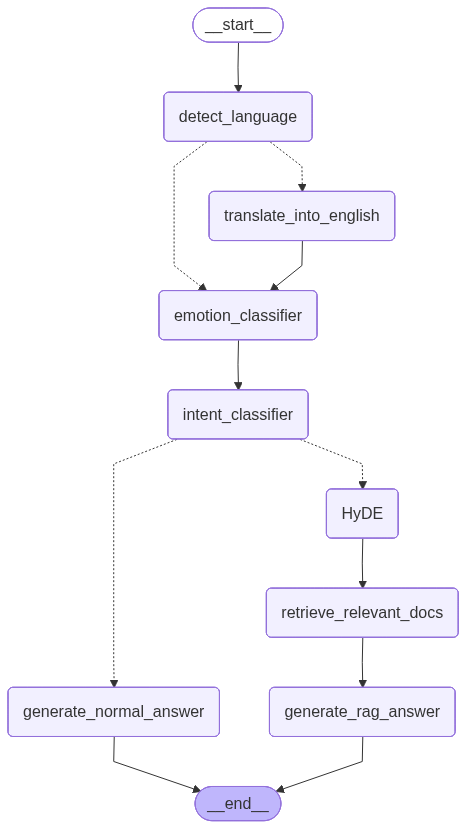

In [52]:
from IPython.display import Image
display(Image(rag_graph.get_graph().draw_mermaid_png()))

In [35]:
output = rag_graph.invoke({
    "question": "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
})

# Evaluating the new workflow

In [36]:
output

{'question': "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
 'retrieved_docs': [Document(metadata={'user_question': 'i get so much anxiety, and i don’t know why. i feel like i can’t do anything by myself because i’m scared of the outcomes.', '_id': '783a8ba0-e554-4dd4-8d2a-a5812f8da672', '_collection_name': 'NLP_Project'}, page_content='The are two ways that such anxiety can be dealt with. One is an attempt to replace maladaptive thinking by examining the distorted thinking and resetting the fight-or-flight response with more reasonable, accurate ones. As an example "I\'m scared of spiders." But if you change the thinking from being scared to "I\'m bigger than the spider," it allows the mind to reach a calmer state of mind.\xa0Mindfulness-based therapy can also help \xa0focus on the bodily sensations that arise when you feel anxious. Instead of avoiding or withdrawing from these feelings, remain present and fully experience the symptoms of anxi

In [38]:
import sys
import langchain_google_vertexai

import langchain_community
if not hasattr(langchain_community, 'chat_models'):
    from types import ModuleType
    langchain_community.chat_models = ModuleType('chat_models')
    sys.modules['langchain_community.chat_models'] = langchain_community.chat_models

import langchain_community.chat_models
langchain_community.chat_models.vertexai = langchain_google_vertexai
sys.modules['langchain_community.chat_models.vertexai'] = langchain_google_vertexai

from ragas.llms import llm_factory

In [44]:
import os
import instructor
from groq import AsyncGroq
from ragas.llms import llm_factory
from ragas.embeddings.base import embedding_factory
from ragas.metrics.collections import ContextRecall
from ragas.metrics.collections import ContextRelevance



raw_async_client = AsyncGroq(
    api_key=os.environ.get("GROQ_API_KEY"),
)


try:
    patched_client = instructor.from_groq(raw_async_client, mode=instructor.Mode.JSON)
except AttributeError:
    patched_client = instructor.from_groq(raw_async_client)

llm = llm_factory(
    model="llama-3.3-70b-versatile", 
    client=patched_client,
    max_tokens=3072
)

llm.is_async = True
llm.client = patched_client

ContextRelevance_scorer = ContextRelevance(llm=llm)
ContextRecall_scorer = ContextRecall(llm=llm)




d:\ITI\projects\NLP_Project\src\.venv\Lib\site-packages\ragas\llms\base.py:556: UserWarning: Client should be an instance of openai.OpenAI or openai.AsyncOpenAI. Unexpected behavior may occur with other client types.
  return instructor.from_openai(client, mode=instructor.Mode.JSON)


In [40]:
user_input = output["question"]
retrieved_contexts = [f"Possible Answers: {doc.page_content}]" for i, doc in enumerate(output["retrieved_docs"])]
reference = "I completely understand how overwhelming this feels, and I am very glad you reached out. When anxiety reaches a point where it feels unhandleable, your immediate priority is to safely ground yourself and seek professional support. To calm your nervous system right now, try to slow down your breathing by inhaling deeply for four seconds, holding for four, and exhaling slowly for six seconds, which sends a biological signal to your brain that you are safe. You can also interrupt racing thoughts by shifting your focus to your surroundings, deliberately naming things you can see, feel, and hear around you. Because you feel like you cannot handle this alone anymore, it is crucial to connect with a therapist or a psychiatrist who can help you build proper coping mechanisms or discuss medication options to reduce your daily distress baseline. Please remember that you do not have to carry this heavy burden by yourself, and if you ever feel unsafe or need instant support, you should immediately reach out to your local emergency services or a mental health crisis hotline."

In [45]:
result = await ContextRelevance_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
)

print(result.value)

1.0


In [46]:
result = await ContextRecall_scorer.ascore(
    user_input= user_input,
    retrieved_contexts=retrieved_contexts,
    reference=reference
)
print(f"Context Recall Score: {result.value}")

Context Recall Score: 0.5


## Using HyDE for it 

In [72]:
hyde_rag = RagGraph().get_agent()

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 4997.22it/s]


In [73]:
output = hyde_rag.invoke({
    "question": "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
})

In [74]:
output

{'question': "My anxiety is really bad and I feel like I can't handle it anymore. What should I do?",
 'translated_question': 'I’m really sorry you’re feeling this way, and I want you to know it’s okay to feel overwhelmed right now—what you’re experiencing matters, and you don’t have to go through it alone. Anxiety can feel all-consuming, but you’ve already taken a brave step by reaching out. Let’s work together to find relief. First, consider contacting a mental health professional for support—therapy, counseling, or medication might help stabilize things. In the moment, try grounding techniques: focus on your breath, name five things you can see, or press your feet into the floor to anchor yourself. Be gentle with yourself—this isn’t a sign of weakness, and healing isn’t linear. You deserve care, and with the right tools, you can regain control. Let’s figure this out step by step.',
 'retrieved_docs': [Document(metadata={'user_question': 'this is preventing me from getting a job. i h

In [75]:
user_input = output["question"]
retrieved_contexts = [f"Possible Answers: {doc.page_content}]" for i, doc in enumerate(output["retrieved_docs"])]
reference = "I completely understand how overwhelming this feels, and I am very glad you reached out. When anxiety reaches a point where it feels unhandleable, your immediate priority is to safely ground yourself and seek professional support. To calm your nervous system right now, try to slow down your breathing by inhaling deeply for four seconds, holding for four, and exhaling slowly for six seconds, which sends a biological signal to your brain that you are safe. You can also interrupt racing thoughts by shifting your focus to your surroundings, deliberately naming things you can see, feel, and hear around you. Because you feel like you cannot handle this alone anymore, it is crucial to connect with a therapist or a psychiatrist who can help you build proper coping mechanisms or discuss medication options to reduce your daily distress baseline. Please remember that you do not have to carry this heavy burden by yourself, and if you ever feel unsafe or need instant support, you should immediately reach out to your local emergency services or a mental health crisis hotline."

In [76]:
retrieved_contexts

["Possible Answers: Overwhelming fear, social anxiety and depression are especially painful because they make behaving constructively a challenge. \xa0But there are also lots of examples of folks who have successfully worked their way through this. \xa0So there is hope! \xa0\xa0In addition to the suggestion to visit your doctor (who may prescribe a medication to help you relax), there are many social service agencies who provide free counseling or take medicaid. \xa0A good CBT therapist will help you look at your thinking so that you may see how you are distorting your thoughts. \xa0Behavior is also important. \xa0Despite how you may feel: it is helpful to go out, to do things that relax you (maybe a yoga class or a meditation class?). \xa0Exercise. Diet. Eat well. Think back on the things that you used to do that helped in the past, and force yourself to do these things again. \xa0I know that this seems hard, but it beats the alternative, doesn't it? \xa0Of course, I recommend you pic

In [77]:
result = await ContextRelevance_scorer.ascore(
    user_input=user_input,
    retrieved_contexts=retrieved_contexts,
)

print(result.value)

1.0


In [78]:
result = await ContextRecall_scorer.ascore(
    user_input= user_input,
    retrieved_contexts=retrieved_contexts,
    reference=reference
)
print(f"Context Recall Score: {result.value}")

Context Recall Score: 0.6666666666666666


### Imporving the question to answer searching by adding HyDe as a point of modification for the user query